Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las
cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image
Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
1. Medición sobre todo el frame.
2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
Opcional:
1. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores
arbitrarios, probar con varios valores 3x3, 7x5, etc … (al menos 3)
Para cada experimento se debe presentar :
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto
de máximo enfoque.
2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure
operators in shapefrom focus.
1. Medicion de foco en toda la imagen
El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera
automática.


In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [16]:
def img_sharpness_measure(img):
  #Dimension del frame
  N = img.shape[0] * img.shape[1]
  #Transformada de Fourier
  F = np.fft.fft2(img)
  #Centrado
  Fc = np.fft.fftshift(F)
  #Valor absoluto de la transformada de Fourier centrada
  AF = np.abs(Fc)
  #Valor máximo
  M = np.max(AF)
  #Contabilizamos los pixeles que superan el threshold
  Th = np.sum(AF > (M/1000))
  return Th/N

In [ ]:
# Carga de video
video_path = 'focus_video.mov'
captura_video = cv2.VideoCapture(video_path)
valuesFull = []

while captura_video.isOpened():
  ret, frame = captura_video.read()
  if ret:
  # Procesamiento básico: convertir a escala de grises

    frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    valuesFull.append(img_sharpness_measure(frame_gris))
  else:
    break
# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()

[np.float64(0.007122395833333333), np.float64(0.007139756944444444), np.float64(0.007131076388888889), np.float64(0.007096354166666667), np.float64(0.0070182291666666665), np.float64(0.006983506944444444), np.float64(0.006983506944444444), np.float64(0.006888020833333334), np.float64(0.006896701388888889), np.float64(0.006861979166666666), np.float64(0.006844618055555555), np.float64(0.006844618055555555), np.float64(0.006844618055555555), np.float64(0.006888020833333334), np.float64(0.006905381944444444), np.float64(0.006818576388888889), np.float64(0.006861979166666666), np.float64(0.006879340277777778), np.float64(0.006888020833333334), np.float64(0.006888020833333334), np.float64(0.006861979166666666), np.float64(0.0069140625), np.float64(0.006957465277777778), np.float64(0.006983506944444444), np.float64(0.007000868055555555), np.float64(0.006983506944444444), np.float64(0.0069921875), np.float64(0.007078993055555555), np.float64(0.007078993055555555), np.float64(0.0071484375), np

#### Roi de 10%
Video es de (360,640) 230400 pixeles con una relacion de 360/640 = 0.5625 por lo tanto:
el 10% son 23040 pixeles

1)x * y = 23040

2)x/y = 0.5625 deben mantener el mismo ratio

x = 0.5625y
Reemplazamos en la ecuacion 1)
0.5625y*y = 23040

y = √(23040/0.5625) = 202

x = 23040/202 = 114

Alto ROI = 114
Ancho ROI = 202

El punto central de imagen original es:
x_centro = 320
y_centro = 180

Por lo tantoa partir del centro generamos el rectangulo que tendra estas coordenadas.

x_izq = 320 - 101 = 219

x_der = 320 + 101 = 421

y_sup = 180 - 57 = 123

y_inf = 180 + 57 = 237


In [11]:
valuesROI = []
x_izq = 219
x_der = 421
y_sup = 123
y_inf = 237
captura_video = cv2.VideoCapture(video_path)
while captura_video.isOpened():
  ret, frame = captura_video.read()
  if ret:
  # Procesamiento básico: convertir a escala de grises
    frame_recortado = frame[y_sup:y_inf,x_izq:x_der]
    frame_gris = cv2.cvtColor(frame_recortado, cv2.COLOR_BGR2GRAY)
    valuesROI.append(img_sharpness_measure(frame_gris))
  else:
    break
# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()

#Graficado

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Buscamos el punto máximo
max_frame_full = np.argmax(valuesFull)
max_value_full = valuesFull[max_frame_full]
max_frame_roi = np.argmax(valuesROI)
max_value_roi = valuesROI[max_frame_roi]

# Preparamos el eje X (lista de números del 0 hasta el total de frames)
eje_x = range(len(valuesROI))

fig,(ax1,ax2) = plt.subplots(1,2, figsize=(15, 5))

# Creamos el gráfico de puntos. 's' controla el tamaño del punto.
ax1.scatter(eje_x, valuesFull, color='green', label='Métrica FM (Full)', s=15)
ax2.scatter(eje_x, valuesROI, color='blue', label='Métrica FM (ROI)', s=15)

# Resaltamos el punto de máximo enfoque con un punto rojo más grande
ax1.scatter(max_frame_full, max_value_full, color='red', label=f'Máximo enfoque (Frame {max_frame_full})', s=60)
ax2.scatter(max_frame_roi, max_value_roi, color='red', label=f'Máximo enfoque (Frame {max_frame_roi})', s=60)



ax1.set_title('Evolución del enfoque en frames completos')
ax1.set_xlabel('Número de Frame')
ax1.set_ylabel('Métrica de Nitidez (FM)')
ax2.set_title('Evolución del enfoque en la Región de Interés')
ax2.set_xlabel('Número de Frame')
ax2.set_ylabel('Métrica de Nitidez (FM)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
ax1.grid(True)
ax2.grid(True)
plt.show()

ValueError: attempt to get argmax of an empty sequence

## Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus.
Varianza del Laplaciano

In [ ]:
valuesLP = []

captura_video = cv2.VideoCapture(video_path)
while captura_video.isOpened():
  ret, frame = captura_video.read()
  if ret:
    frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(frame_gris, cv2.CV_64F)
    valuesLP.append(np.var(laplacian))
  else:
    break
# Libera el objeto de captura de video
captura_video.release()
cv2.destroyAllWindows()


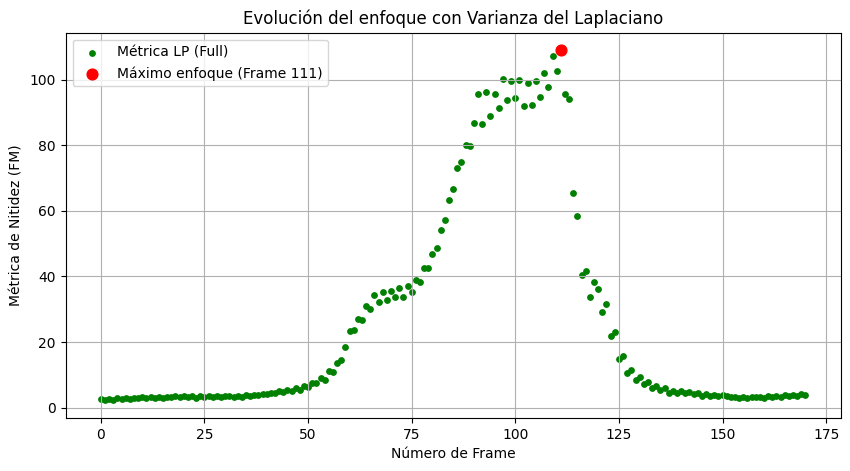

In [ ]:
# Buscamos el punto máximo
max_frame_LP = np.argmax(valuesLP)
max_value_LP = valuesLP[max_frame_LP]


# Preparamos el eje X (lista de números del 0 hasta el total de frames)
eje_x = range(len(valuesLP))

plt.figure(figsize=(10,5))

# Creamos el gráfico de puntos. 's' controla el tamaño del punto.
plt.scatter(eje_x, valuesLP, color='green', label='Métrica LP (Full)', s=15)


# Resaltamos el punto de máximo enfoque con un punto rojo más grande
plt.scatter(max_frame_LP, max_value_LP, color='red', label=f'Máximo enfoque (Frame {max_frame_LP})', s=60)


plt.title('Evolución del enfoque con Varianza del Laplaciano')
plt.xlabel('Número de Frame')
plt.ylabel('Métrica de Nitidez (FM)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()